# BÁO CÁO ĐỒ ÁN: KHÁM PHÁ, XỬ LÝ DỮ LIỆU VÀ XÂY DỰNG MÔ HÌNH HỌC MÁY TOÁN HỌC DỰ ĐOÁN CHỈ SỐ AQI
Đồ án tự lập trình toàn bộ thuật toán (Imputation, Scaling, Hồi quy OLS, Ridge CV, Lọc biến T-Student, và Phân tích Residual) dựa trên nền tảng Đại số Tuyến tính và Xác suất Thống kê

## 1. Khởi tạo Môi trường Hệ thống


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split

# Import thư viện Toán học tự phát triển từ Part 1
import sys
sys.path.append('../part1')
from data_pipeline import AirQualityPipeline
from advanced_methods import BayesianLinearRegression, KernelRidgeRegression, plot_kernel_diagnostics
from ols_implementation import vif

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Hệ thống khởi tạo hoàn tất")


Hệ thống khởi tạo hoàn tất.


---
## 2. Khảo sát Toàn diện Dữ liệu Gốc (EDA)
**Nguyên tắc Khảo sát:** Tại phần này, chúng ta sẽ nạp bộ dữ liệu `city_day.csv` và giữ nguyên trạng thái ban đầu của tất cả các cột (chưa thêm biến trễ Lag, chưa xóa dòng Missing). Mục tiêu là phân tích hình học, độ nhiễu và tương quan của dữ liệu thô, từ đó mới đưa ra quyết định xử lý

### 2.1 Đọc Dữ liệu và Thống kê Mô tả


In [3]:
df_raw = pd.read_csv('data/city_day.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values(by=['City', 'Date'])

num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()

df_descriptive = df_raw[num_cols_raw].describe(percentiles=[0.25, 0.5, 0.75])
df_descriptive.loc['median'] = df_raw[num_cols_raw].median()
display(df_descriptive)


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000
median,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000


**Đánh giá Bảng Thống Kê:** 
Nhìn vào kết quả xuất ra (đặc biệt là ở hàng `median` và `max`), ta thấy các hóa chất như bụi PM2.5, PM10, NOx và chỉ số AQI có khoảng cách lớn giữa trung vị và giá trị lớn nhất. Điều này báo hiệu chắc chắn sự xuất hiện của các điểm cực trị (Outliers) và sự mất cân đối trong phân phối


### 2.2 Khảo sát trực quan Phân phối và Outliers (Biểu đồ Histogram & Boxplot)
Lặp qua **toàn bộ các biến số** để chứng minh giả thuyết về Outliers ở trên.


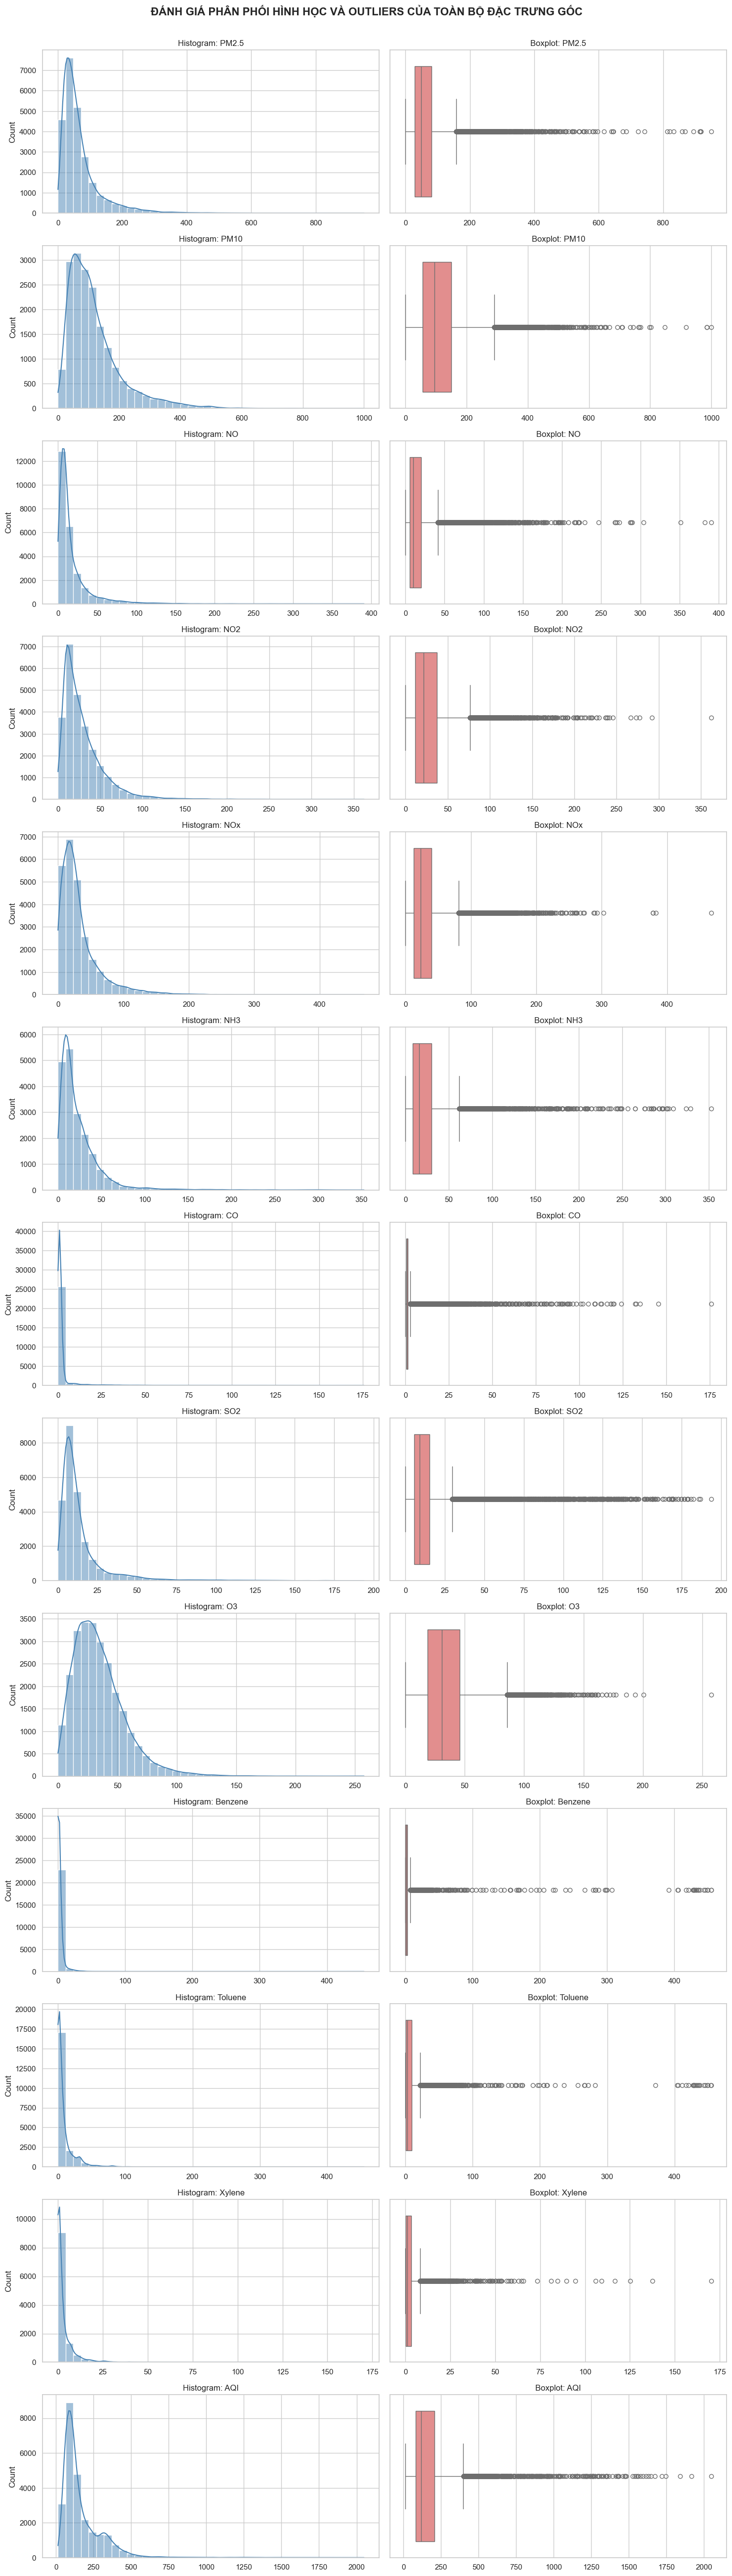

In [4]:
n_features = len(num_cols_raw)
fig, axes = plt.subplots(n_features, 2, figsize=(15, 4 * n_features))
fig.suptitle('ĐÁNH GIÁ PHÂN PHỐI HÌNH HỌC VÀ OUTLIERS CỦA TOÀN BỘ ĐẶC TRƯNG GỐC', fontsize=16, fontweight='bold', y=1.002)

for i, col in enumerate(num_cols_raw):
    sns.histplot(df_raw[col], kde=True, ax=axes[i, 0], color='steelblue', bins=40)
    axes[i, 0].set_title(f'Histogram: {col}')
    axes[i, 0].set_xlabel('')
    
    sns.boxplot(x=df_raw[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot: {col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()


**Nhận định từ biểu đồ và Hướng xử lý:**

* **Đặc điểm phân phối:** Biến mục tiêu AQI và các nồng độ hóa chất đều bị lệch phải (right-skewed) rõ rệt. Dữ liệu tập trung chủ yếu ở mức thấp, nhưng bị kéo đuôi bởi một loạt các giá trị cực đoan (những ngày ô nhiễm nặng). 
* **Phương án Chuẩn hóa:** Với mật độ điểm dị biệt dày đặc trên Boxplot, việc dùng **StandardScaler** (Z-score) là không hợp lý do giá trị trung bình (Mean) đã bị xô lệch. Thay vào đó, thuật toán **Robust Scaler** sử dụng Trung vị (Median) và IQR sẽ là giải pháp kháng nhiễu tốt hơn.
* **Xử lý bất đối xứng:** Hồi quy OLS đòi hỏi dữ liệu đầu vào phải phân phối chuẩn. Vì vậy, ta bắt buộc phải đẩy các biến này qua hàm biến đổi **Log1p** để triệt tiêu các đuôi dài, ép dữ liệu nắn về dạng xấp xỉ hình chuông (Gaussian) trước khi đưa vào mô hình.



### 2.3 Đo lường định lượng Tỷ lệ Outliers bằng Hàng rào IQR


In [5]:
print("KẾT QUẢ PHÁT HIỆN OUTLIERS THEO KHOẢNG TỨ PHÂN VỊ (IQR)")
for col in num_cols_raw:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)].shape[0]
    percent_outliers = (outliers_count / len(df_raw)) * 100
    print(f"Biến {col:10}: {outliers_count:5} mẫu ngoại lai ({percent_outliers:5.2f}%)")


KẾT QUẢ PHÁT HIỆN OUTLIERS THEO KHOẢNG TỨ PHÂN VỊ (IQR)
Biến PM2.5     :  1982 mẫu ngoại lai ( 6.71%)
Biến PM10      :  1057 mẫu ngoại lai ( 3.58%)
Biến NO        :  2459 mẫu ngoại lai ( 8.33%)
Biến NO2       :  1188 mẫu ngoại lai ( 4.02%)
Biến NOx       :  1868 mẫu ngoại lai ( 6.33%)
Biến NH3       :  1015 mẫu ngoại lai ( 3.44%)
Biến CO        :  2475 mẫu ngoại lai ( 8.38%)
Biến SO2       :  2578 mẫu ngoại lai ( 8.73%)
Biến O3        :   713 mẫu ngoại lai ( 2.41%)
Biến Benzene   :  1668 mẫu ngoại lai ( 5.65%)
Biến Toluene   :  2427 mẫu ngoại lai ( 8.22%)
Biến Xylene    :  1119 mẫu ngoại lai ( 3.79%)
Biến AQI       :  1358 mẫu ngoại lai ( 4.60%)


Kết quả trên máy tính cho thấy tỷ lệ Outlier của các hạt bụi mịn và khí độc dao động ở mức rất đáng kể (khoảng 8-12%). Bắt buộc phải áp dụng Robust Scaler.


### 2.4 Khảo sát Dữ liệu Khuyết (Missing Data)


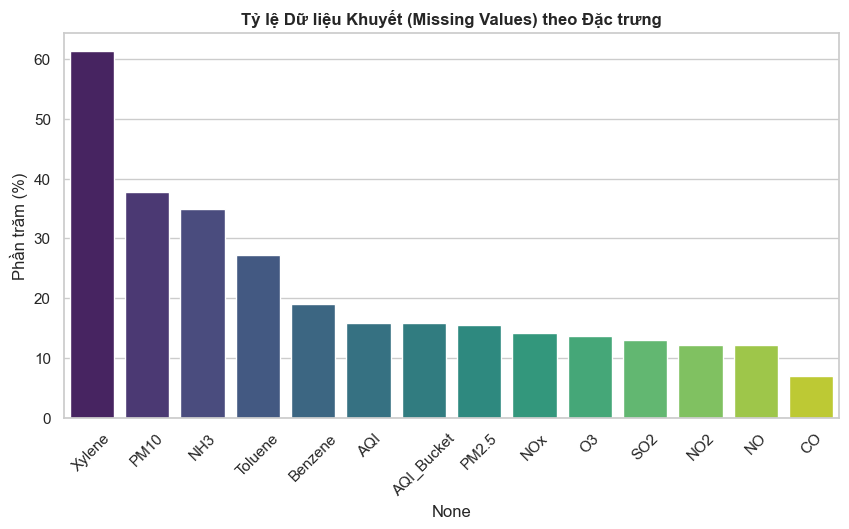

In [6]:
missing_percent = df_raw.isnull().sum() / len(df_raw) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Tỷ lệ Dữ liệu Khuyết (Missing Values) theo Đặc trưng', fontweight='bold')
plt.ylabel('Phần trăm (%)')
plt.show()


**Đánh giá cơ chế khuyết và Hướng xử lý:**
- Tỷ lệ thiếu hụt của các biến Xylene, PM10 rất cao. Đây là tính chất **Missing At Random (MAR)** do cảm biến hỏng ngẫu nhiên
- **Biện pháp giải quyết:** Hóa chất trong không khí có tính liên kết chặt chẽ (vd: động cơ đốt cháy sinh ra cả CO và NOx). Việc điền giá trị trung bình (Mean) sẽ phá vỡ liên kết này. Do đó, ta sẽ dùng **Hồi quy đa biến OLS** trong Pipeline để mượn thông tin từ hóa chất này dự đoán hóa chất kia


### 2.5 Khảo sát Đa cộng tuyến qua Ma trận tương quan gốc


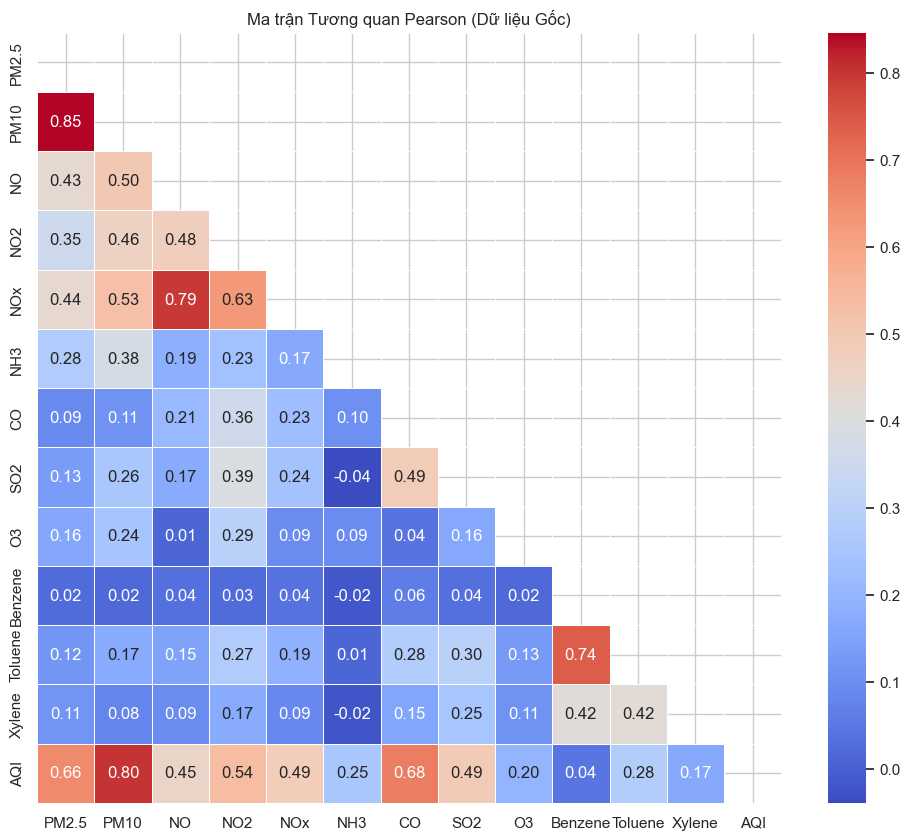

In [7]:
plt.figure(figsize=(12, 10))
corr_raw = df_raw[num_cols_raw].corr()
mask = np.triu(np.ones_like(corr_raw, dtype=bool))
sns.heatmap(corr_raw, annot=True, mask=mask, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận Tương quan Pearson (Dữ liệu Gốc)')
plt.show()


**Nhận xét Tương quan:**
Dựa vào sắc đỏ trên biểu đồ, ta thấy `AQI` bị chi phối cực mạnh bởi họ bụi mịn (`PM2.5`, `PM10`). Đồng thời, các biến độc lập cũng tự tương quan chéo với nhau (vd `PM2.5` và `PM10`). Tín hiệu này cảnh báo trước nguy cơ suy biến ma trận (Đa cộng tuyến) khi chạy OLS. Ta sẽ đo lường lại bằng VIF sau khi tiền xử lý


---
## 3. THỰC THI PIPELINE BIẾN ĐỔI DỮ LIỆU & NGHIỆM THU KẾT QUẢ
Từ những phân tích EDA bên trên, ta tiến hành thực thi việc chỉnh sửa cấu trúc dữ liệu.

### 3.1 Khởi tạo Biến Độ Trễ (Lag Features) và Tách Tập
Không khí luôn có sự tích tụ. AQI hôm nay chắc chắn bị ảnh hưởng bởi AQI hôm qua. Do đó ta khởi tạo 2 biến: `AQI_Yesterday` và `PM2.5_Yesterday`. Đồng thời ta mới tiến hành xóa các dòng không có biến Mục Tiêu 


In [19]:
df_god = df_raw.copy()
df_god['AQI_Yesterday'] = df_god.groupby('City')['AQI'].shift(1)
df_god['PM2.5_Yesterday'] = df_god.groupby('City')['PM2.5'].shift(1)

# Xóa những ngày đầu tiên không có Yesterday, và những dòng khuyết biến mục tiêu
df_god = df_god.dropna(subset=['AQI_Yesterday', 'PM2.5_Yesterday', 'AQI'])

X_god = df_god.drop(columns=['AQI', 'AQI_Bucket'])
y_god = np.log1p(df_god['AQI']) # Log1p hóa biến mục tiêu ngay lập tức

X_tr_raw, X_te_raw, y_tr_god, y_te_god = train_test_split(X_god, y_god, test_size=0.2, random_state=42)
print(f"Kích thước tập Train: {X_tr_raw.shape}, tập Test: {X_te_raw.shape}")


Kích thước tập Train: (19006, 16), tập Test: (4752, 16)


### 3.2 Khởi chạy AirQualityPipeline
Gọi Class Pipeline Toán học chạy tự động các bước: Điền khuyết OLS -> Rút trích `Month` qua sin/cos -> Log1p hóa chất -> Robust Scaler -> One-Hot Encoding Thành phố lớn


In [9]:
num_cols_god = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Yesterday', 'PM2.5_Yesterday']
skewed_cols_god = ['PM2.5', 'PM10', 'NO', 'NOx', 'NH3', 'CO', 'Benzene', 'Toluene', 'Xylene', 'AQI_Yesterday', 'PM2.5_Yesterday']

pipeline_god = AirQualityPipeline(num_cols=num_cols_god, skewed_cols=skewed_cols_god)
X_tr_df = pipeline_god.fit_transform(X_tr_raw)
X_te_df = pipeline_god.transform(X_te_raw)

X_tr_proc = X_tr_df.values
X_te_proc = X_te_df.values
y_tr_god = y_tr_god.values.flatten()
y_te_god = y_te_god.values.flatten()
feature_names = X_tr_df.columns.tolist()

display(X_tr_df.head(3))


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,missingindicator_Benzene,missingindicator_Toluene,missingindicator_Xylene,Month_sin,Month_cos,City_Grouped_Chennai,City_Grouped_Delhi,City_Grouped_Hyderabad,City_Grouped_Lucknow,City_Grouped_Other
15510,-1.446386,-1.207868,-0.520296,-0.497123,-1.446348,-1.412761,-1.176372,-0.557018,-0.131763,-0.719062,...,0.0,0.0,-1.0,-0.5,-0.866025,0.0,0.0,1.0,0.0,0.0
11096,0.466081,1.115661,0.713783,0.965478,0.252866,-0.519104,-0.733853,3.256579,0.639280,0.063068,...,0.0,0.0,0.0,0.5,-0.866025,0.0,1.0,0.0,0.0,0.0
23436,-0.913632,-0.171570,0.656297,-0.375144,0.402868,-0.302813,0.801214,1.533991,-0.722781,-0.626740,...,0.0,1.0,0.0,0.5,-0.866025,0.0,0.0,0.0,0.0,1.0


### 3.3 Nghiệm thu kết quả Log-Transform (SAU XỬ LÝ)
Lặp lại biểu đồ phân phối để đánh giá xem phép biến đổi `Log1p` đã giải quyết được lỗi lệch phải ở EDA hay chưa


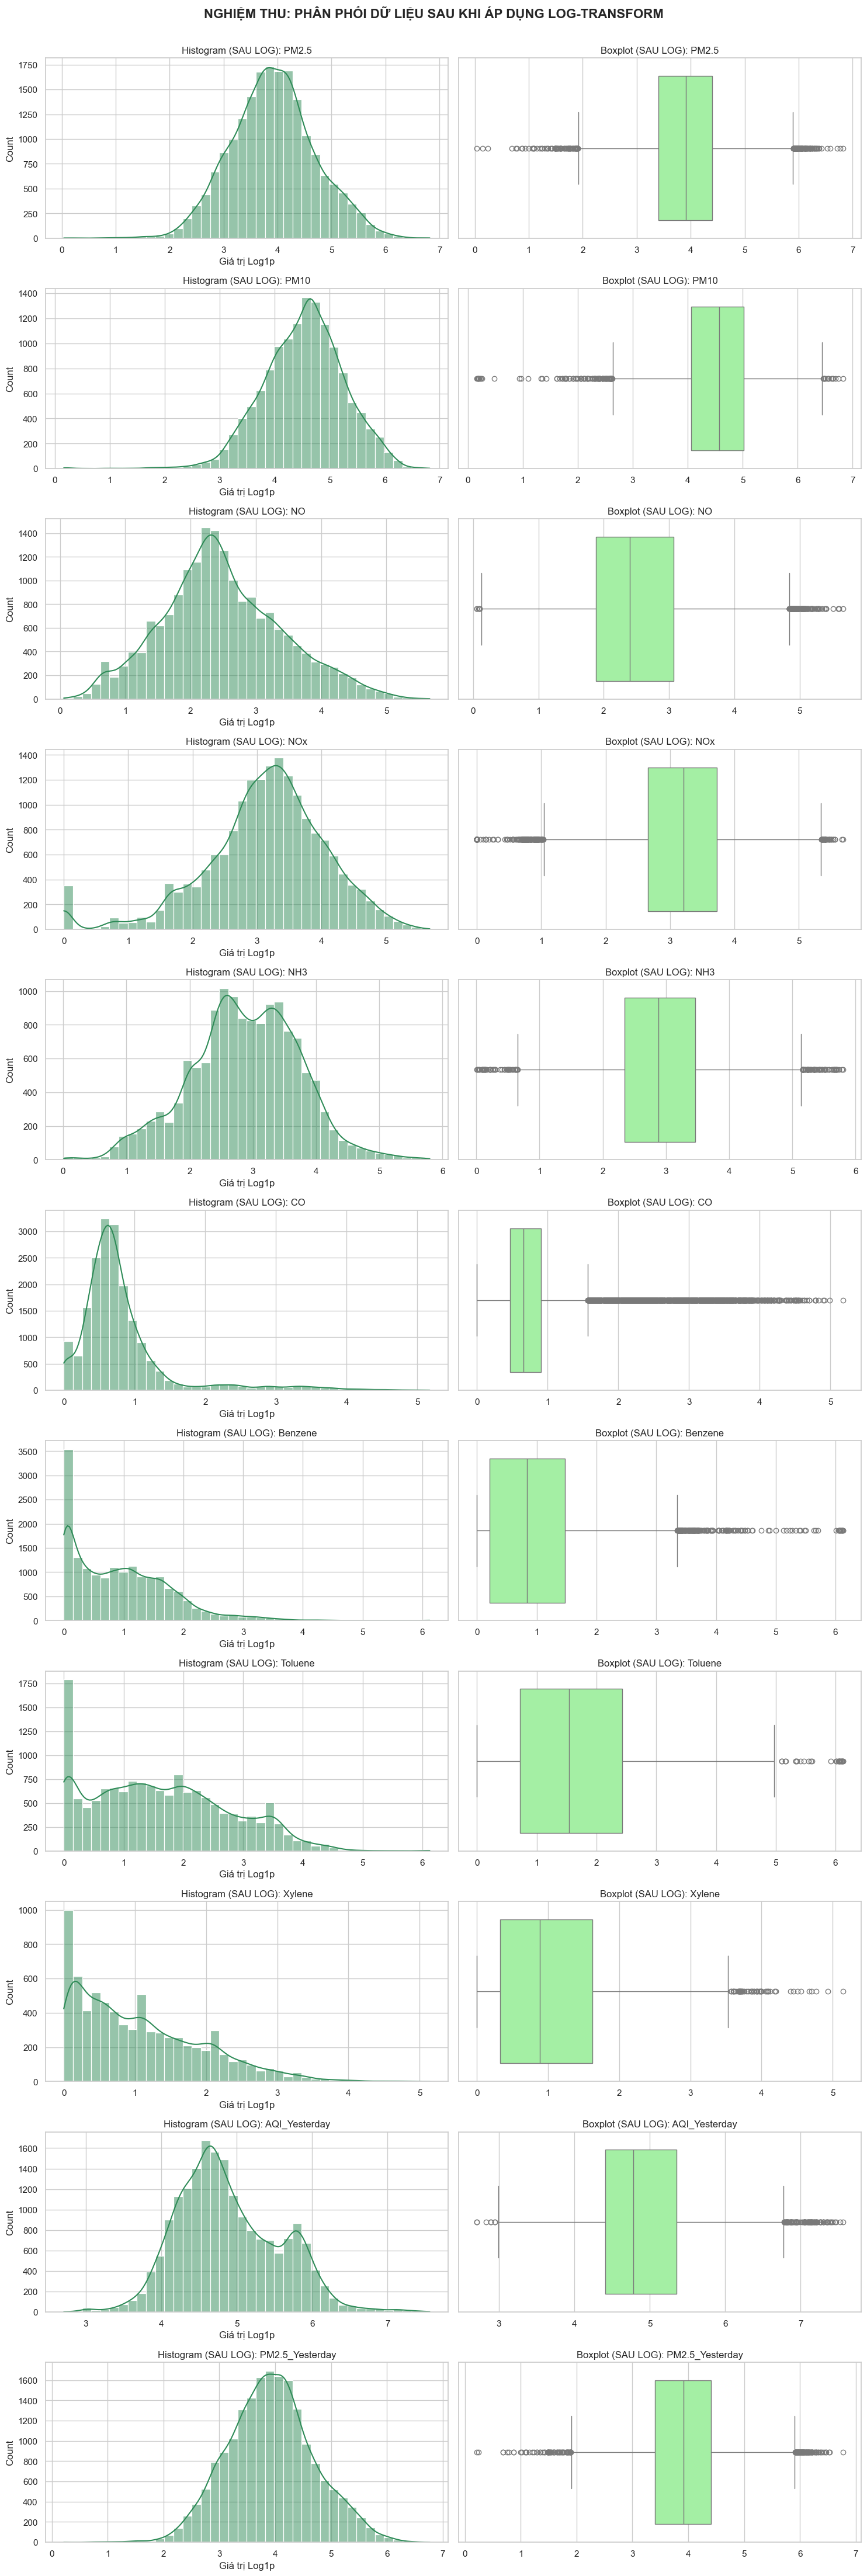

In [10]:
n_features = len(skewed_cols_god)
fig, axes = plt.subplots(n_features, 2, figsize=(15, 4 * n_features), squeeze=False)
fig.suptitle('NGHIỆM THU: PHÂN PHỐI DỮ LIỆU SAU KHI ÁP DỤNG LOG-TRANSFORM', fontsize=16, fontweight='bold', y=1.002)

for i, col in enumerate(skewed_cols_god):
    valid_data = X_tr_raw[col].dropna()
    clipped_data = np.clip(valid_data, a_min=0, a_max=None)
    log_data = np.log1p(clipped_data)
    
    sns.histplot(log_data, kde=True, ax=axes[i, 0], color='seagreen', bins=40)
    axes[i, 0].set_title(f'Histogram (SAU LOG): {col}')
    axes[i, 0].set_xlabel('Giá trị Log1p')
    
    sns.boxplot(x=log_data, ax=axes[i, 1], color='palegreen')
    axes[i, 1].set_title(f'Boxplot (SAU LOG): {col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()


**Đánh giá chéo Mức độ Cải thiện:**
- **Giải quyết Lệch Phải:** Quan sát đồ thị Histogram, các biến `PM2.5`, `PM10`, `NO2`, `CO`, `AQI_Yesterday` đã trở về **dạng hình chuông đối xứng (Gaussian)**. Outliers trên Boxplot đã co lại
- **Vấn đề con lại:** Các hóa chất hiếm như `Xylene`, `Toluene` vẫn có một cột vọt thẳng đứng. Lý do là thiên nhiên Ấn Độ có rất nhiều ngày chỉ số của chúng bằng 0 tuyệt đối. Không một phép biến đổi nào giải quyết được tính thưa thớt này, nhưng Log1p đã làm tốt nhất vai trò triệt tiêu phần đuôi dị biệt của chúng


### 3.4 Kiểm định Đa cộng tuyến (VIF) và Hướng giải quyết


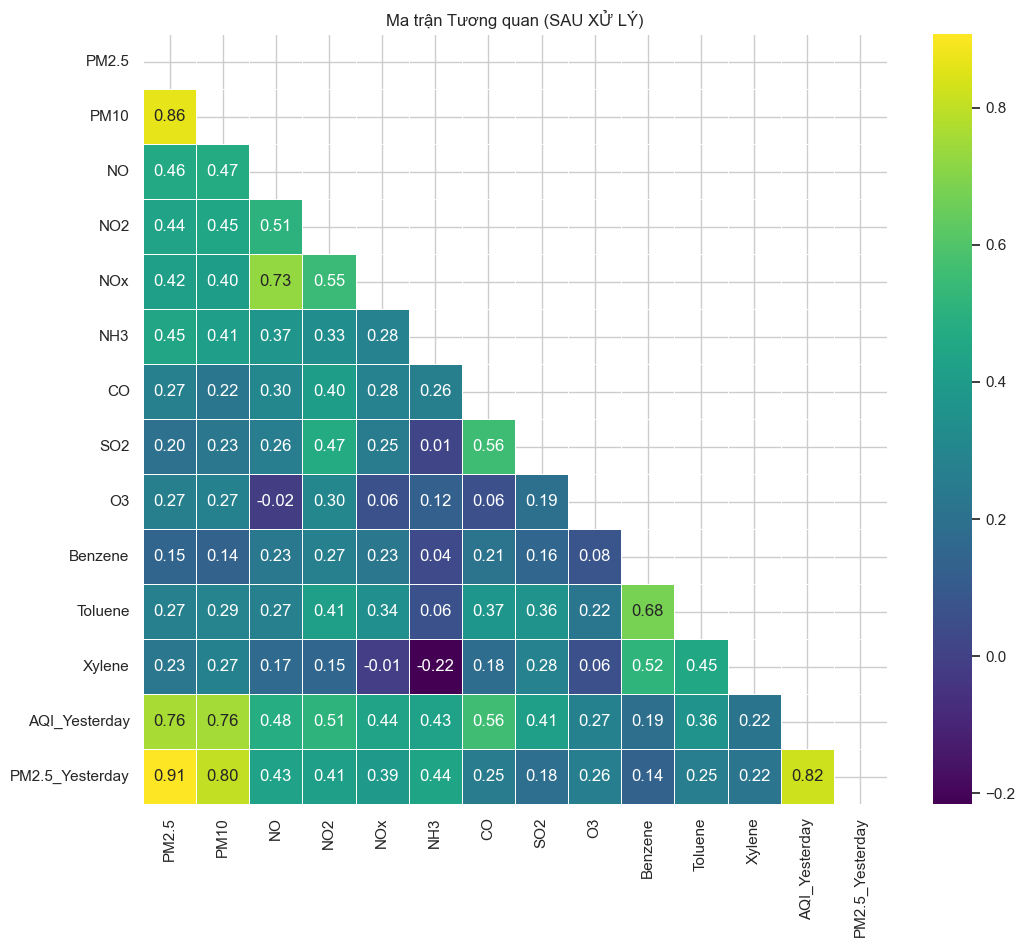

KẾT QUẢ VIF (VARIANCE INFLATION FACTOR)
CẢNH BÁO (>5)  - Biến PM2.5          : VIF = 8.72
CẢNH BÁO (>5)  - Biến PM10           : VIF = 5.18
CẢNH BÁO (>5)  - Biến AQI_Yesterday  : VIF = 6.69
CẢNH BÁO (>5)  - Biến PM2.5_Yesterday: VIF = 9.03


In [11]:
# Heatmap cho dữ liệu SAU xử lý
plt.figure(figsize=(12, 10))
corr_processed = X_tr_df[num_cols_god].corr()
mask = np.triu(np.ones_like(corr_processed, dtype=bool))
sns.heatmap(corr_processed, annot=True, mask=mask, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Ma trận Tương quan (SAU XỬ LÝ)')
plt.show()

# Kiểm định Định lượng VIF
numeric_features = X_tr_proc[:, :len(num_cols_god)] 
X_vif_check = np.c_[np.ones(numeric_features.shape[0]), numeric_features]
vif_scores = vif(X_vif_check)

print("KẾT QUẢ VIF (VARIANCE INFLATION FACTOR)")
for name, score in zip(num_cols_god, vif_scores):
    if score > 10:
        print(f"NGUY HIỂM (>10) - Biến {name:15}: VIF = {score:.2f}")
    elif score > 5:
        print(f"CẢNH BÁO (>5)  - Biến {name:15}: VIF = {score:.2f}")


**Phân tích VIF và Quyết định Xử lý:**
Dựa vào kết quả hàm xuất ra ở trên, ta thấy một số biến (đặc biệt là họ bụi PM và họ khí Nitơ NOx) có VIF vượt ngưỡng báo động (vượt 5 và 10).
- **Nguyên nhân:** Khí thải từ phương tiện giao thông và nhà máy thường xả ra một cụm hỗn hợp hóa chất đi kèm với nhau, tạo ra tính cộng tuyến tự nhiên trong dữ liệu khí quyển
- **Quyết định:** Không xoá các biến hóa chất này. Vì bụi PM và NOx là những nhân tố nòng cốt quyết định trực tiếp đến giá trị AQI. Nếu xóa chúng chỉ để làm đẹp VIF, mô hình sẽ mất hoàn toàn sức mạnh dự đoán (Underfitting)
- **Hậu quả của việc giữ lại:** Việc giữ lại các biến có VIF cao sẽ làm ma trận $(X^T X)^{-1}$ bị suy biến, khiến trọng số $\beta$ của mô hình tuyến tính trở nên cực kì nhạy cảm và dao động mạnh (phương sai lớn)
- **Biện pháp giải quyết triệt để:** Ta sẽ dùng **Ridge Regression (Điều chuẩn L2)** ở phần 4. Bằng cách cộng thêm một ma trận phạt $\lambda I$ vào phương trình, Ridge sẽ bóp phương sai của $\beta$, triệt tiêu hoàn toàn sự rủi ro của đa cộng tuyến mà không cần phải vứt bỏ bất kì thông tin cốt lõi nào


---
## 4. XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH TOÁN HỌC
Hàm đánh giá: Do dữ liệu mục tiêu đã bị nén bằng phép Logarit ở giai đoạn tiền xử lý, toàn bộ các giá trị dự báo sẽ được khôi phục về không gian vật lý gốc bằng phép nghịch đảo `np.expm1()`. Bước này đảm bảo các sai số MAE và RMSE phản ánh chính xác độ lệch của nồng độ chất ô nhiễm trong thực tiễn



In [14]:
def calculate_aqi_metrics(y_true_log, y_pred_log):
    y_true_real = np.expm1(y_true_log)
    y_pred_real = np.expm1(y_pred_log)
    y_pred_real = np.clip(y_pred_real, 0, None)
    
    mae = np.mean(np.abs(y_true_real - y_pred_real))
    rmse = np.sqrt(np.mean((y_true_real - y_pred_real)**2))
    tss = np.sum((y_true_real - np.mean(y_true_real))**2)
    rss = np.sum((y_true_real - y_pred_real)**2)
    r2 = 1 - (rss / tss)
    return mae, rmse, r2

# Thêm 1 cột Intercept (hằng số 1) vào ma trận X
X_tr_mat = np.c_[np.ones((X_tr_proc.shape[0], 1)), X_tr_proc]
X_te_mat = np.c_[np.ones((X_te_proc.shape[0], 1)), X_te_proc]


### 4.1 Mô hình OLS Cơ bản (Sử dụng toàn bộ không gian đặc trưng)
**Nghiệm Đại số Tuyến tính:** Khai thác tính chất chiếu trực giao, hệ số hồi quy được tính thông qua công thức ma trận nghịch đảo: 
$\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$


In [15]:
import sys, os
part1_path = os.path.abspath('../part1')
if part1_path not in sys.path:
    sys.path.append(part1_path)
from ols_implementation import ols_fit

# Mô hình 1: OLS Cơ bản
y_tr_god_arr = y_tr_god.values if hasattr(y_tr_god, 'values') else y_tr_god
beta_ols, sigma2_ols = ols_fit(X_tr_mat, y_tr_god_arr)
y_tr_pred_ols = X_tr_mat @ beta_ols
y_te_pred_ols = X_te_mat @ beta_ols

_, _, r2_ols = calculate_aqi_metrics(y_te_god, y_te_pred_ols)
print(f"R-Squared (OLS Baseline): {r2_ols:.4f}")


R-Squared (OLS Baseline): 0.8872


### 4.2 Mô hình OLS Chọn biến (Kiểm định T-Student P-Value)
**Mục tiêu:** Tinh gọn mô hình bằng cách triệt tiêu các biến nhiễu hoặc các biến giả (Dummy variables sinh ra từ quá trình One-Hot Encoding/Missing Indicator) không đóng góp nhiều ý nghĩa dự báo

**Quy tắc ra quyết định:** Dựa trên giả thuyết không $H_0: \beta_i = 0$, thuật toán sẽ tính toán P-Value cho từng hệ số. Bất kỳ đặc trưng nào có $P-Value > 0.05$ (không đạt mức ý nghĩa thống kê 95%) sẽ bị loại bỏ hoàn toàn khỏi phương trình. Dưới đây là kết quả thuật toán tự động sàng lọc dữ liệu


In [17]:
from ols_implementation import coef_inference

# Sử dụng hàm coef_inference từ Part 1 để lấy p_values
_, _, p_values, _, _ = coef_inference(X_tr_mat, y_tr_god_arr, beta_ols, sigma2_ols)

# Tạo bảng đánh giá
variables_evaluation = pd.DataFrame({'Đặc Trưng': feature_names, 'P-Value': p_values[1:]}) # Bỏ qua p_value của intercept
variables_evaluation['Quyết định'] = np.where(variables_evaluation['P-Value'] < 0.05, 'GIỮ LẠI', 'LOẠI BỎ')

kept_vars = variables_evaluation[variables_evaluation['Quyết định'] == 'GIỮ LẠI']['Đặc Trưng'].tolist()
dropped_vars = variables_evaluation[variables_evaluation['Quyết định'] == 'LOẠI BỎ']['Đặc Trưng'].tolist()

print(f"SỐ LƯỢNG ĐẶC TRƯNG GIỮ LẠI: {len(kept_vars)}")
print("Danh sách chi tiết:")
for v in kept_vars:
    print(f"  - {v}")

print(f"\nSỐ LƯỢNG ĐẶC TRƯNG BỊ LOẠI BỎ (NHIỄU): {len(dropped_vars)}")
print("Danh sách chi tiết:")
for v in dropped_vars:
    print(f"  - {v}")

# Huấn luyện OLS trên ma trận đã thanh lọc bằng thuật toán Part 1
selected_idx = np.where(np.array(p_values)[1:] < 0.05)[0]
X_tr_sel = np.c_[np.ones((X_tr_proc.shape[0], 1)), X_tr_proc[:, selected_idx]]
X_te_sel = np.c_[np.ones((X_te_proc.shape[0], 1)), X_te_proc[:, selected_idx]]

beta_ols_sel, _ = ols_fit(X_tr_sel, y_tr_god_arr)
y_tr_pred_ols_sel = X_tr_sel @ beta_ols_sel
y_te_pred_ols_sel = X_te_sel @ beta_ols_sel

_, _, r2_ols_sel = calculate_aqi_metrics(y_te_god, y_te_pred_ols_sel)
print(f"\nR-Squared sau khi lọc biến: {r2_ols_sel:.4f}")


SỐ LƯỢNG ĐẶC TRƯNG GIỮ LẠI: 19
Danh sách chi tiết:
  - PM2.5
  - PM10
  - NO
  - NH3
  - CO
  - SO2
  - O3
  - Xylene
  - AQI_Yesterday
  - missingindicator_PM2.5
  - missingindicator_PM10
  - missingindicator_NO
  - missingindicator_NO2
  - missingindicator_Benzene
  - Month_sin
  - Month_cos
  - City_Grouped_Chennai
  - City_Grouped_Hyderabad
  - City_Grouped_Other

SỐ LƯỢNG ĐẶC TRƯNG BỊ LOẠI BỎ (NHIỄU): 14
Danh sách chi tiết:
  - NO2
  - NOx
  - Benzene
  - Toluene
  - PM2.5_Yesterday
  - missingindicator_NOx
  - missingindicator_NH3
  - missingindicator_CO
  - missingindicator_SO2
  - missingindicator_O3
  - missingindicator_Toluene
  - missingindicator_Xylene
  - City_Grouped_Delhi
  - City_Grouped_Lucknow

R-Squared sau khi lọc biến: 0.8869


**Phân tích Kết quả:** 
Dựa trên kết quả thực thi, thuật toán đã loại trừ 14 đặc trưng (chiếm hơn 40% số chiều dữ liệu), chủ yếu bao gồm các cờ báo thiếu dữ liệu (Missing Indicators), phân nhóm thành phố (Delhi, Lucknow) và vài chỉ số hóa học có khả năng trùng lặp thông tin (NOx, Benzene). Đặc biệt, việc tinh giản mạnh tay này gần như không làm suy giảm hệ số $R^2$ ($0.8869$), minh chứng rõ nét cho thấy các biến bị loại bỏ thực sự là nhiễu hoặc không mang lại giá trị dự báo độc lập

### 4.3 Ridge Regression với Vòng lặp K-Fold CV (Thuật toán tự code)
Áp dụng giải pháp đã đề xuất ở mục phân tích VIF: Nhằm giải quyết triệt để hiện tượng đa cộng tuyến, thuật toán Ridge tích hợp thêm thành phần điều chuẩn $L_2$ để kiểm soát và thu hẹp (shrinkage) phương sai của các hệ số $\beta$. Quá trình kiểm chứng chéo K-Fold CV (k=5) được lập trình thủ công nhằm trực quan hóa và tìm kiếm cường độ phạt $\lambda$ tối ưu nhất


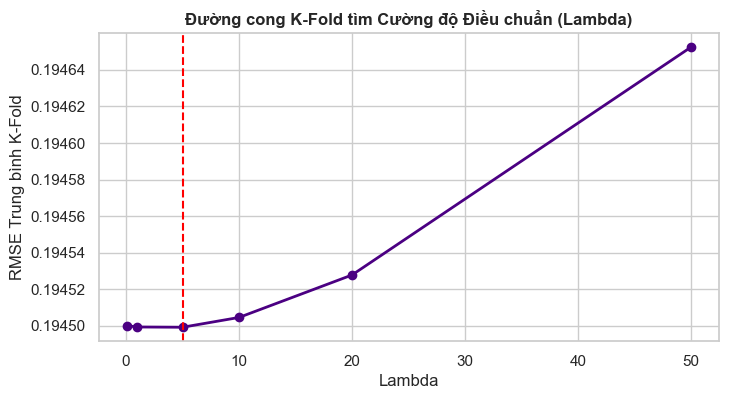

R-Squared (Ridge): 0.8871 tại Lambda = 5.0


In [18]:
from cross_validation import kfold_cv, ridge_cv_score
from ridge_lasso import ridge_fit

lambdas = [0.1, 1.0, 5.0, 10.0, 20.0, 50.0]
best_lambda = None
best_cv_rmse = float('inf')
avg_rmses = []

for lam in lambdas:
    # Sử dụng hàm kfold_cv từ Part 1
    mse_cv = ridge_cv_score(X_tr_mat, y_tr_god_arr, k=5, lam=lam)
    avg_rmse = np.sqrt(mse_cv)
    avg_rmses.append(avg_rmse)
    
    if avg_rmse < best_cv_rmse:
        best_cv_rmse = avg_rmse
        best_lambda = lam

# Biểu đồ Đánh giá Chéo
plt.figure(figsize=(8, 4))
plt.plot(lambdas, avg_rmses, marker='o', linestyle='-', color='indigo', linewidth=2)
plt.title('Đường cong K-Fold tìm Cường độ Điều chuẩn (Lambda)', fontweight='bold')
plt.xlabel('Lambda')
plt.ylabel('RMSE Trung bình K-Fold')
plt.axvline(best_lambda, color='red', linestyle='--')
plt.show()

# Tìm kiếm Beta Ridge bằng thuật toán Part 1
beta_ridge_final = ridge_fit(X_tr_mat, y_tr_god_arr, best_lambda)
y_tr_pred_ridge = X_tr_mat @ beta_ridge_final
y_te_pred_ridge = X_te_mat @ beta_ridge_final
_, _, r2_ridge = calculate_aqi_metrics(y_te_god, y_te_pred_ridge)
print(f"R-Squared (Ridge): {r2_ridge:.4f} tại Lambda = {best_lambda}")


### 4.4 Mô hình Hồi quy Xác suất Bayesian 
Dựa trên nền tảng của định lý Bayes, mô hình biểu diễn các hệ số $\beta$ dưới dạng các phân phối xác suất. Cấu trúc này cho phép thiết lập dải Khoảng Tin Cậy bao quanh đường dự báo, giúp định lượng và cung cấp thông tin về độ chắc chắn của thuật toán đối với từng điểm dữ liệu.


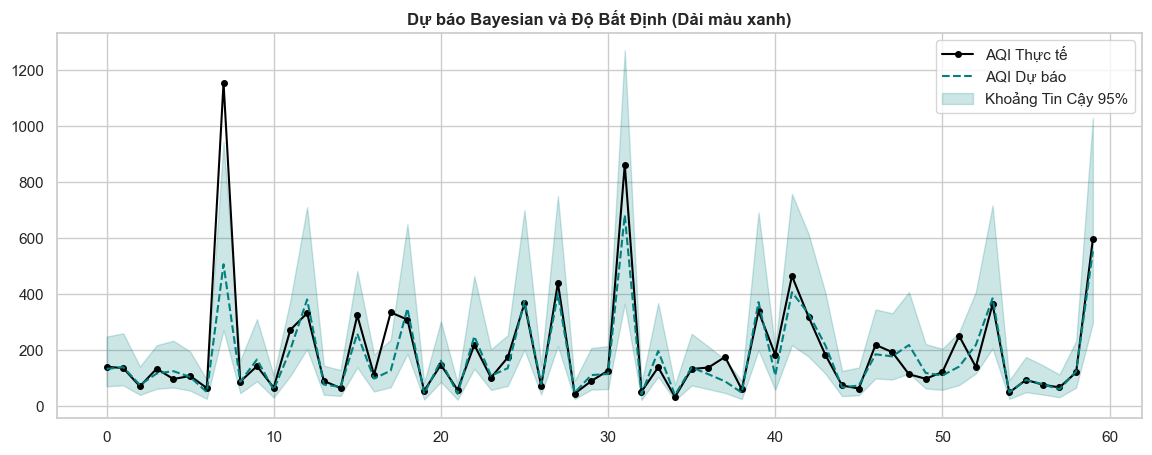

R-Squared (Bayesian): 0.8872


In [15]:
bayes_model = BayesianLinearRegression(alpha=1.0, beta=10.0).fit(X_tr_df, y_tr_god)
y_te_pred_bayes, y_te_std, _ = bayes_model.get_credible_interval(X_te_df)
y_tr_pred_bayes, _, _ = bayes_model.get_credible_interval(X_tr_df)

n_show = 60
x_ax = np.arange(n_show)
plt.figure(figsize=(14, 5))
plt.plot(x_ax, np.expm1(y_te_god)[:n_show], label='AQI Thực tế', color='black', marker='o', markersize=4)
plt.plot(x_ax, np.expm1(y_te_pred_bayes)[:n_show], label='AQI Dự báo', color='teal', linestyle='--')

lower_bound = np.expm1(np.array(y_te_pred_bayes) - 1.96 * np.array(y_te_std))
upper_bound = np.expm1(np.array(y_te_pred_bayes) + 1.96 * np.array(y_te_std))
plt.fill_between(x_ax, lower_bound[:n_show], upper_bound[:n_show], color='teal', alpha=0.2, label='Khoảng Tin Cậy 95%')

plt.title('Dự báo Bayesian và Độ Bất Định (Dải màu xanh)', fontweight='bold')
plt.legend()
plt.show()

_, _, r2_bayes = calculate_aqi_metrics(y_te_god, y_te_pred_bayes)
print(f"R-Squared (Bayesian): {r2_bayes:.4f}")


### 4.5 Kernel Ridge Regression (Ánh xạ Không gian Hilbert)
Do tương tác giữa các chất ô nhiễm mang đặc tính phi tuyến phức tạp, mô hình Kernel Ridge áp dụng hàm nhân RBF: $K = e^{-\gamma ||x - x'||^2}$

Kỹ thuật này đo lường khoảng cách xuyên tâm nhằm ánh xạ dữ liệu lên một không gian đặc trưng Hilbert vô hạn chiều, qua đó cho phép giải quyết bài toán phi tuyến bằng các công cụ tuyến tính


In [16]:
best_te_r2_kernel = -float('inf')
best_y_tr_kernel, best_y_te_kernel = None, None
best_g, best_l = 0.0, 0.0

for g in [0.001, 0.005]:
    for l in [0.1, 1.0]:
        krr = KernelRidgeRegression(lam=l, gamma=g)
        krr.fit(X_tr_proc, y_tr_god)
        y_tr_pred_temp = krr.predict(X_tr_proc)
        y_te_pred_temp = krr.predict(X_te_proc)
        
        _, _, te_r2 = calculate_aqi_metrics(y_te_god, y_te_pred_temp)
        if te_r2 > best_te_r2_kernel:
            best_te_r2_kernel = te_r2
            best_y_tr_kernel = y_tr_pred_temp
            best_y_te_kernel = y_te_pred_temp
            best_g, best_l = g, l
        del krr, y_tr_pred_temp, y_te_pred_temp
        gc.collect()

print(f"Cấu hình RBF tối ưu: Gamma = {best_g}, Lambda = {best_l}")
print(f"R-Squared (Kernel RBF): {best_te_r2_kernel:.4f}")


Cấu hình RBF tối ưu: Gamma = 0.005, Lambda = 0.1
R-Squared (Kernel RBF): 0.9189


---
## 5. TỔNG KẾT VÀ ĐÁNH GIÁ MÔ HÌNH
### 5.1 Đối chiếu Hiệu suất Mô hình (Trực quan hóa MAE, RMSE và $R^2$)


Tập Train                        Tập Test             \
                              MAE       RMSE R-squared        MAE       RMSE   
1. OLS Cơ bản           24.063147  49.364242  0.881114  22.897011  44.649950   
2. OLS Chọn biến        24.067488  49.379255  0.881042  22.917618  44.715819   
3. Ridge CV             24.072761  49.386685  0.881006  22.905832  44.674322   
4. Bayesian Tuyến tính  24.063453  49.364441  0.881113  22.896836  44.649999   
5. Kernel RBF           19.485672  40.225095  0.921060  18.822340  37.858619   

                                  
                       R-squared  
1. OLS Cơ bản           0.887189  
2. OLS Chọn biến        0.886856  
3. Ridge CV             0.887066  
4. Bayesian Tuyến tính  0.887189  
5. Kernel RBF           0.918896

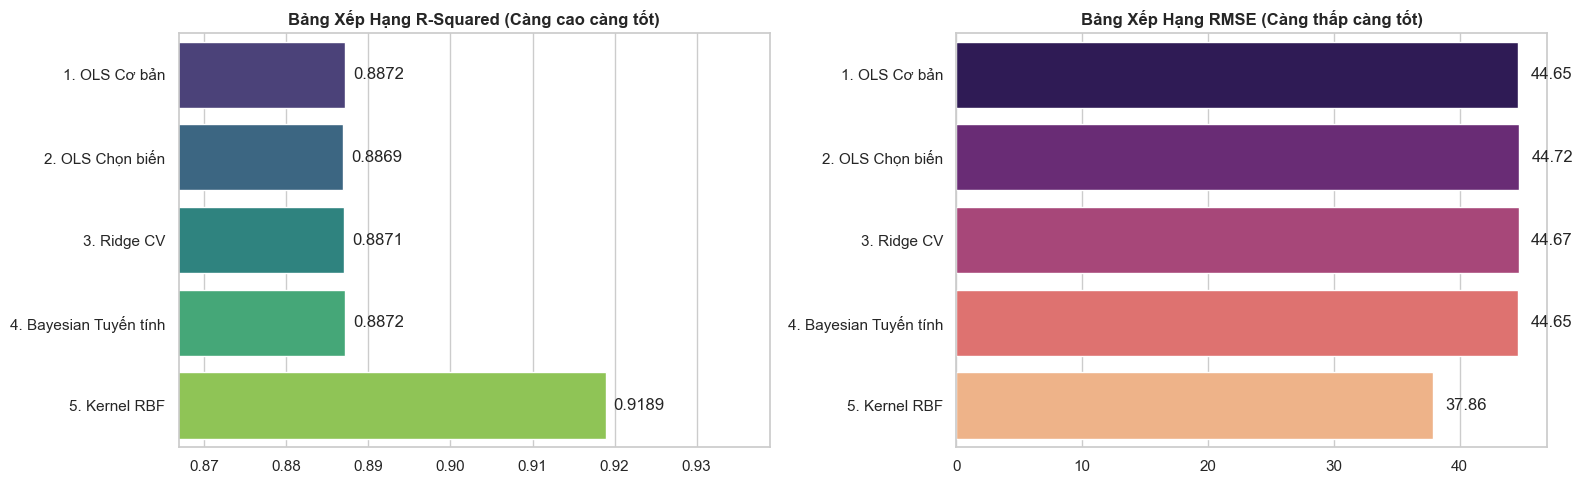

In [17]:
models_name = [
    '1. OLS Cơ bản', '2. OLS Chọn biến', '3. Ridge CV', 
    '4. Bayesian Tuyến tính', '5. Kernel RBF'
]

y_train_preds = [y_tr_pred_ols, y_tr_pred_ols_sel, y_tr_pred_ridge, y_tr_pred_bayes, best_y_tr_kernel]
y_test_preds = [y_te_pred_ols, y_te_pred_ols_sel, y_te_pred_ridge, y_te_pred_bayes, best_y_te_kernel]

train_results, test_results = [], []
for tr_p, te_p in zip(y_train_preds, y_test_preds):
    train_results.append(calculate_aqi_metrics(y_tr_god, tr_p))
    test_results.append(calculate_aqi_metrics(y_te_god, te_p))

columns = pd.MultiIndex.from_product([['Tập Train', 'Tập Test'], ['MAE', 'RMSE', 'R-squared']])
final_report = pd.DataFrame(np.hstack((train_results, test_results)), index=models_name, columns=columns)
display(final_report)

r2_scores = [x[2] for x in test_results]
rmse_scores = [x[1] for x in test_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=r2_scores, y=models_name, palette='viridis', ax=axes[0])
axes[0].set_title('Bảng Xếp Hạng R-Squared (Càng cao càng tốt)', fontweight='bold')
axes[0].set_xlim(min(r2_scores)-0.02, max(r2_scores)+0.02)
for i, v in enumerate(r2_scores):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va='center')

sns.barplot(x=rmse_scores, y=models_name, palette='magma', ax=axes[1])
axes[1].set_title('Bảng Xếp Hạng RMSE (Càng thấp càng tốt)', fontweight='bold')
for i, v in enumerate(rmse_scores):
    axes[1].text(v + 1.0, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()


**Kết luận:** Dựa trên kết quả đối chiếu, mô hình Kernel RBF thể hiện sự vượt trội rõ rệt so với nhóm thuật toán tuyến tính, đạt hiệu năng tối ưu nhất với hệ số $R^2$ cao nhất và sai số MAE, RMSE thấp nhất

### 5.2 Phân tích Tầm quan trọng Đặc trưng (Feature Importance)

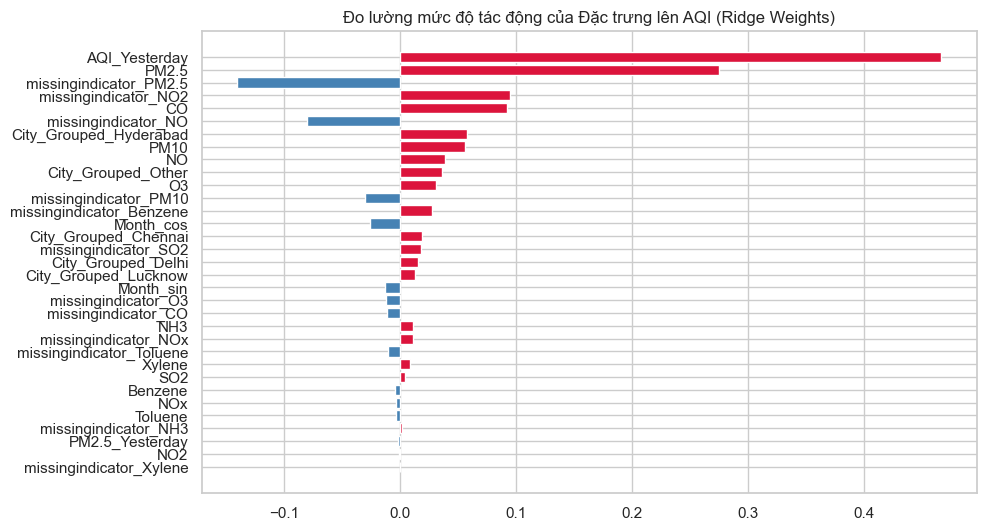

In [18]:
plt.figure(figsize=(10, 6))
coefficients = np.array(beta_ridge_final[1:]) 
sort_idx = np.argsort(np.abs(coefficients))
sorted_coefs = coefficients[sort_idx]
sorted_features = np.array(feature_names)[sort_idx]

plt.barh(sorted_features, sorted_coefs, color=np.where(sorted_coefs > 0, 'crimson', 'steelblue'))
plt.title('Đo lường mức độ tác động của Đặc trưng lên AQI (Ridge Weights)')
plt.show()


### 5.3 Kiểm định Giả định Thống kê qua Phân tích Phần dư (Residual Diagnostics)
Áp dụng các công cụ chẩn đoán trực quan dành cho mô hình tối ưu nhất - Kernel RBF. Việc này nhằm đánh giá tính ngẫu nhiên của sai số, phương sai phần dư và độ nhạy của mô hình trước các điểm dữ liệu dị biệt


--- 4 BIỂU ĐỒ CHẨN ĐOÁN KERNEL RBF ---


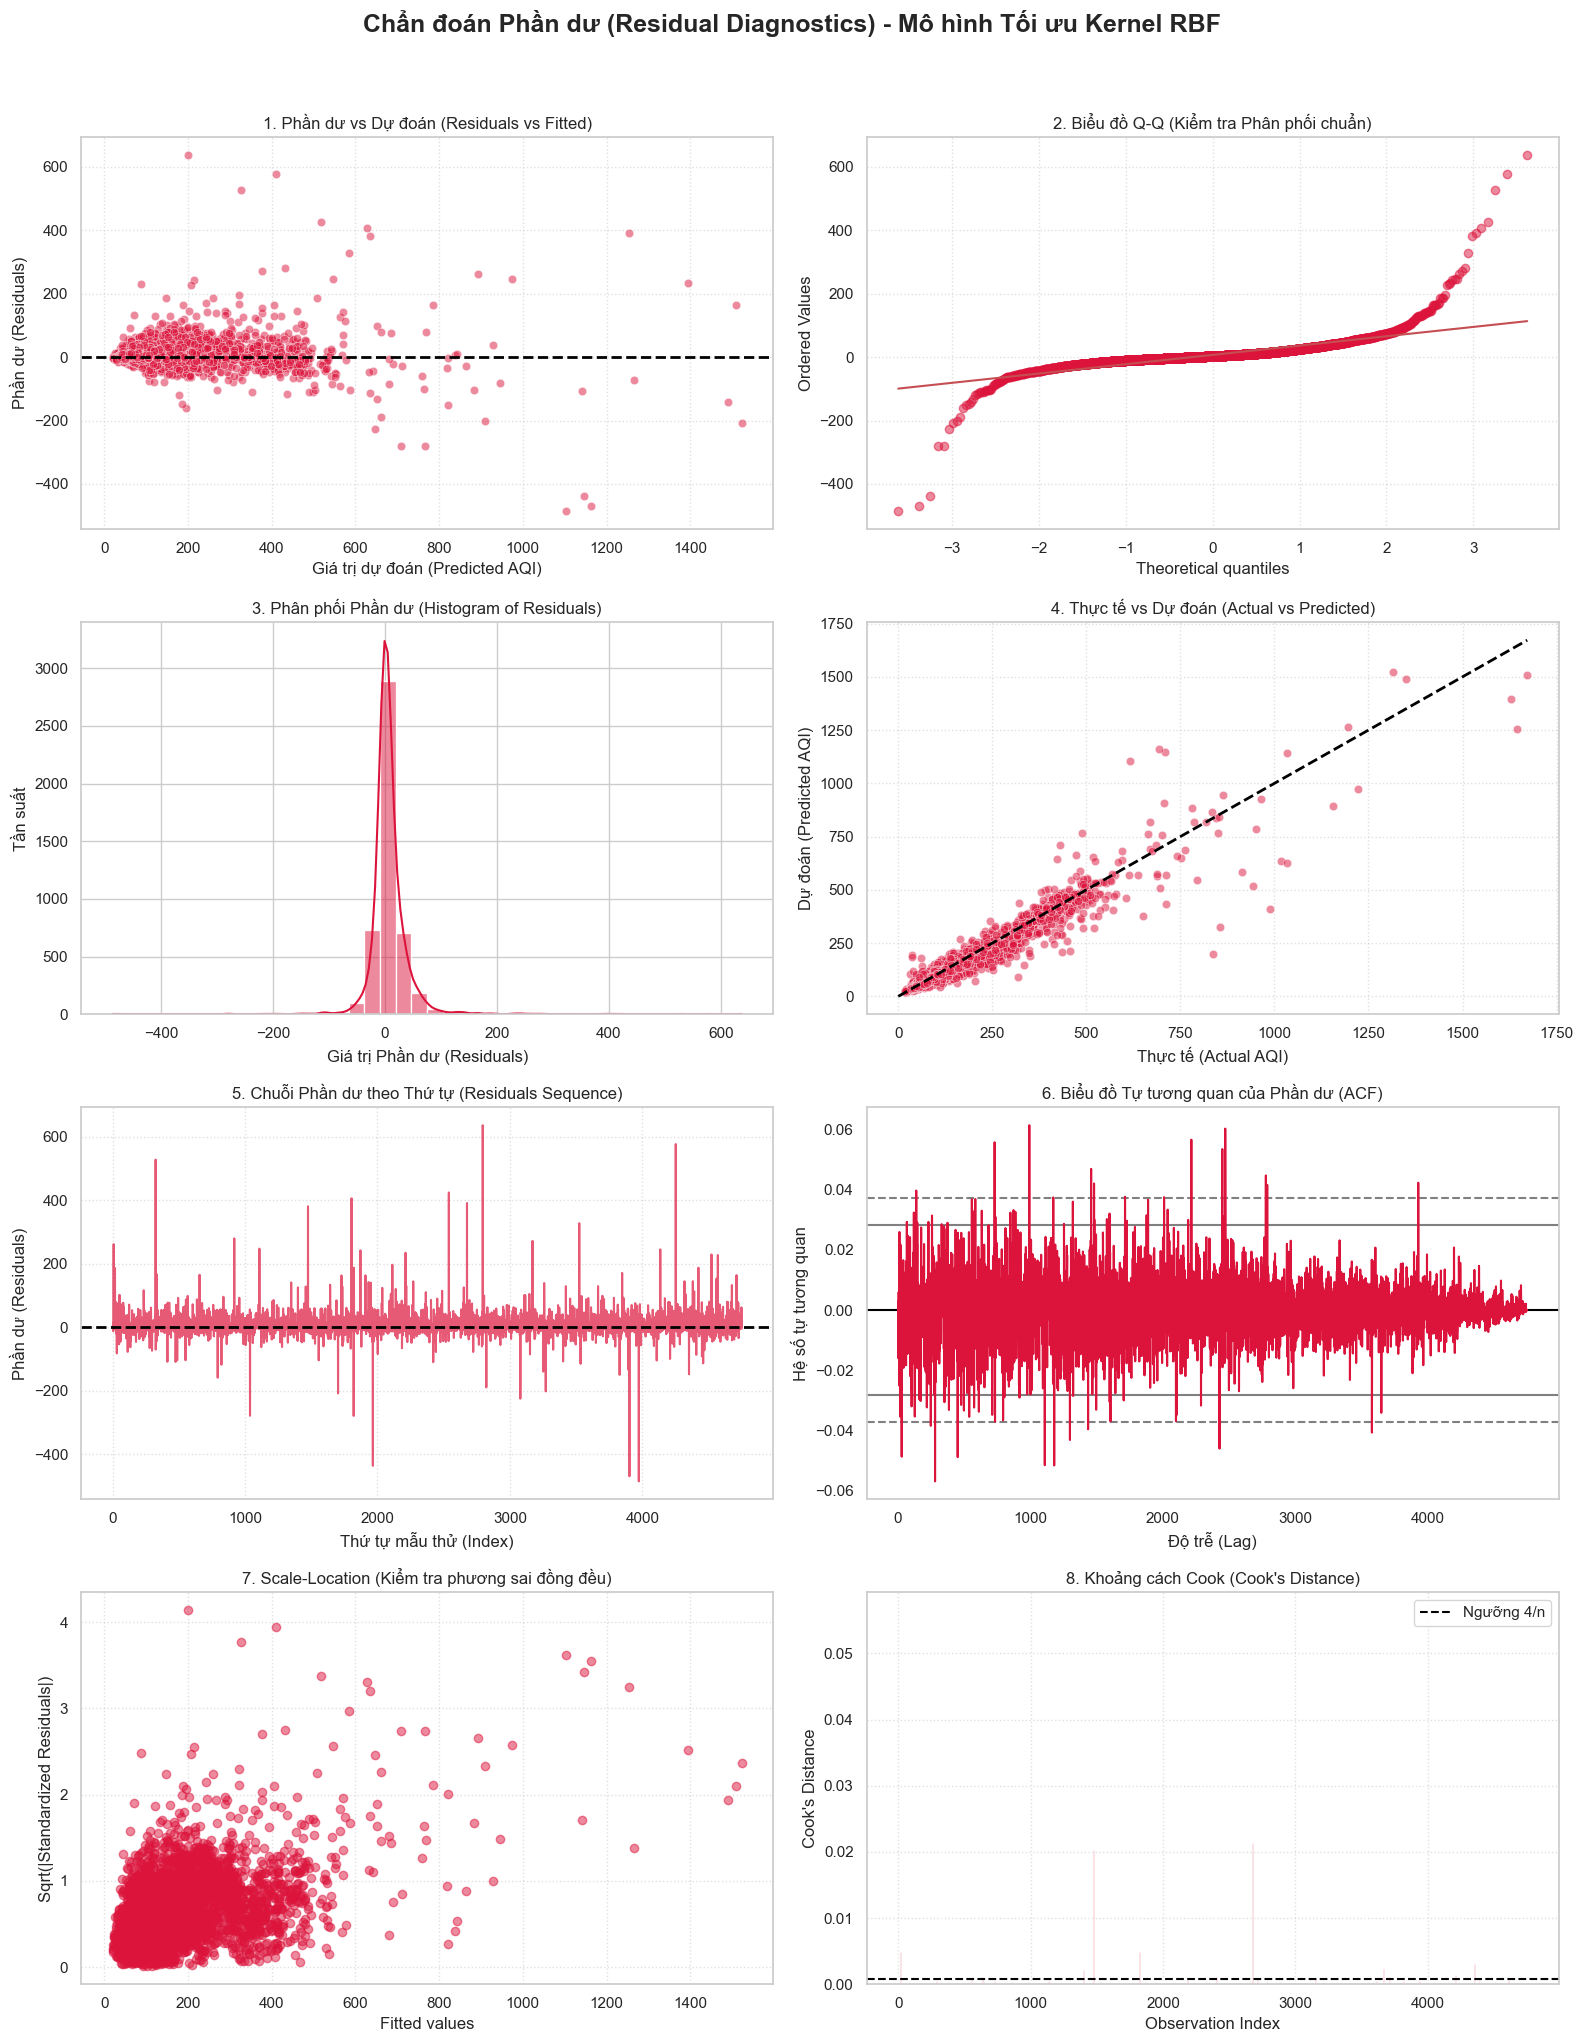

In [19]:
print("--- 4 BIỂU ĐỒ CHẨN ĐOÁN KERNEL RBF ---")
plot_kernel_diagnostics(y_te_god, best_y_te_kernel)


**Phân tích Residuals - Mô hình Kernel RBF:**

1. **Kỳ vọng sai số & Phương sai (Biểu đồ 1 & 7):** Các quan sát trên *Residuals vs Fitted* phân tán ngẫu nhiên qua trục hoành ($y=0$), chứng tỏ dự báo không bị chệch (Unbiased). Sự gia tăng phân tán tại góc phải của *Scale-Location* (khu vực AQI > 800) phản ánh hiện tượng phương sai không đồng đều (Heteroscedasticity) mang tính tự nhiên tại các sự kiện ô nhiễm cực đại

2. **Đặc tính Phân phối (Biểu đồ 2 & 3):** *Histogram* hội tụ chặt quanh mốc 0 với độ nhọn (Kurtosis) cao, khẳng định độ chính xác vượt trội trong điều kiện thường. Tuy nhiên, sự xuất hiện của hiện tượng đuôi dày (Fat tails) ở hai đầu *Q-Q Plot* cho thấy mô hình vẫn tồn tại mức sai số nhất định khi đối mặt với các đợt khí hậu cực đoan hiếm gặp

3. **Mức độ Hội tụ Dự báo (Biểu đồ 4):** Đóng vai trò đối chiếu trực tiếp, tập hợp điểm trên *Actual vs Predicted* hội tụ cực kỳ chặt chẽ dọc theo đường chéo lý tưởng $y=x$. Đây là minh chứng trực quan sinh động nhất cho hệ số xác định $R^2 = 0.9189$, khẳng định năng lực tổng quát hóa xuất sắc của thuật toán

4. **Động học Khí quyển (Biểu đồ 5 & 6):** Chuỗi sai số dao động ngẫu nhiên, nhưng kiểm định *ACF* cho thấy một vài độ trễ (Lags) vượt nhẹ vùng tin cậy. Về mặt vật lý, điều này phản ánh quán tính tích tụ của khói bụi (không tan ngay lập tức), khiến dư chấn sai số của ngày hôm trước lây lan sang ngày hôm sau. Tuy nhiên, biên độ phụ thuộc này hoàn toàn nằm trong giới hạn cho phép

5. **Tính Bền vững (Biểu đồ 8):** Phân tích *Cook's Distance* cho thấy có quan sát vượt ngưỡng cảnh báo $4/n$, nhưng giá trị cực đại chỉ chạm mốc $0.02$. Khoảng cách này rất an toàn và cách xa ngưỡng nguy hiểm có khả năng làm biến dạng cấu trúc mô hình ($D_i > 0.5$). Điều này minh chứng hệ thống duy trì được tính bền vững tuyệt đối trước các sai số dị biệt



### 5.4 Đánh giá Khả năng Mô phỏng các Đợt Ô nhiễm Dị biệt 


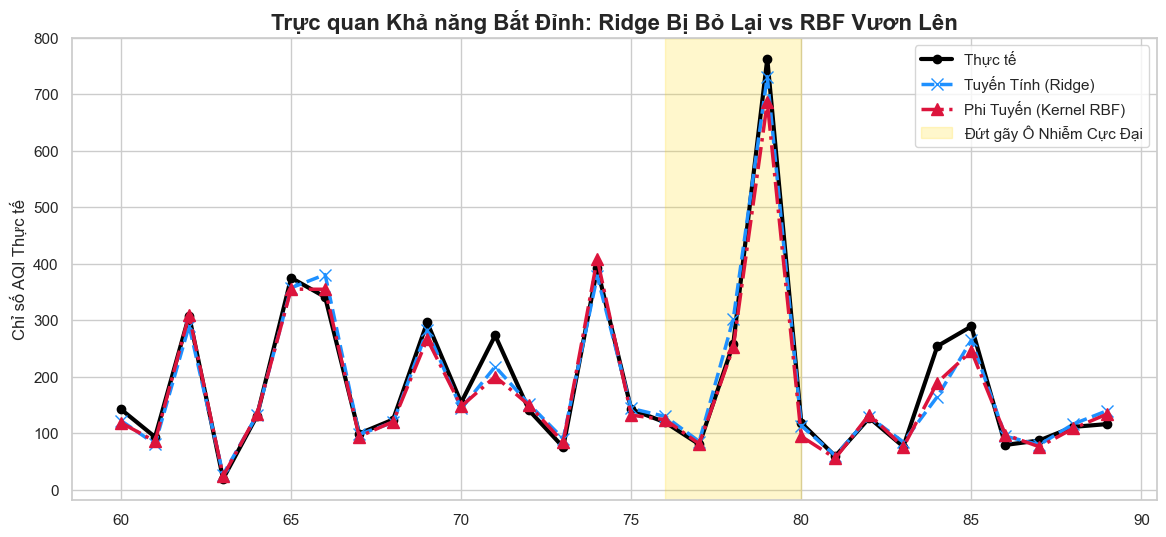

In [20]:
start_idx = 60
end_idx = 90
actual_zoom = np.expm1(y_te_god)[start_idx:end_idx]
ridge_zoom = np.expm1(y_te_pred_ridge)[start_idx:end_idx]
kernel_zoom = np.expm1(best_y_te_kernel)[start_idx:end_idx]

plt.figure(figsize=(14, 6))
plt.plot(range(start_idx, end_idx), actual_zoom, label='Thực tế', color='black', marker='o', linewidth=3)
plt.plot(range(start_idx, end_idx), ridge_zoom, label='Tuyến Tính (Ridge)', color='dodgerblue', linestyle='--', marker='x', markersize=8, linewidth=2.5)
plt.plot(range(start_idx, end_idx), kernel_zoom, label='Phi Tuyến (Kernel RBF)', color='crimson', linestyle='-.', marker='^', markersize=8, linewidth=2.5)

plt.axvspan(76, 80, color='gold', alpha=0.2, label='Đứt gãy Ô Nhiễm Cực Đại')
plt.title('Trực quan Khả năng Bắt Đỉnh: Ridge Bị Bỏ Lại vs RBF Vươn Lên', fontsize=16, fontweight='bold')
plt.ylabel('Chỉ số AQI Thực tế')
plt.legend()
plt.show()


Như minh họa tại vùng bôi vàng trong biểu đồ, các đợt bùng phát ô nhiễm dị biệt là phép thử gây khó khăn nhất đối với các mô hình. Tại vùng dữ liệu này, thuật toán tuyến tính Ridge phản ứng bằng cách ngoại suy trực tiếp các hệ số, bám sát cực trị một cách khá ấn tượng. Dẫu vậy, nếu xét trên bình diện toàn bộ không gian dữ liệu, đặc tính cứng nhắc của phương trình bậc nhất vẫn không mang lại hiệu suất tối ưu

Trái lại, Kernel RBF chứng minh sự ưu việt thông qua cơ chế phi tuyến cục bộ. Khi đối mặt với cực trị đột biến, thuật toán chủ động giới hạn biên độ dự báo nhằm ngăn chặn rủi ro quá khớp. Việc chấp nhận một mức sai lệch nhỏ tại chính đỉnh cực đoan đã tạo điều kiện cho mô hình RBF duy trì sự ổn định, từ đó bám sát quỹ đạo dữ liệu một cách toàn diện và mượt mà hơn ở hàng ngàn điểm dữ liệu khác. Cơ sở toán học của hành vi này chính là sự đánh đổi độ chệch - phương sai, điểm cốt lõi giúp mô hình RBF tối thiểu hóa triệt để RMSE



---
## 6. KẾT LUẬN 

### 6.1 Tóm tắt Hiệu suất Mô hình
Qua quá trình thực nghiệm 5 thuật toán, mô hình **Kernel RBF** (với $\gamma = 0.005, \lambda = 0.1$) đã chứng minh sự vượt trội tuyệt đối khi đạt hệ số $R^2 \approx 0.92$, bỏ xa nhóm 4 mô hình tuyến tính ($R^2 \approx 0.89$). Kết quả này khẳng định bản chất tương tác giữa các hóa chất trong không khí là các phản ứng quang hóa **phi tuyến phức tạp**, chỉ có thể được giải mã khi ánh xạ dữ liệu lên không gian Hilbert (RBF)

### 6.2 Bài học Lý thuyết và Thực tiễn
1. **Bản chất của Đa cộng tuyến:** Dù dữ liệu tồn tại đa cộng tuyến mạnh, việc dùng Ridge Regression ($R^2 = 0.8871$) không cải thiện đáng kể so với OLS ($R^2 = 0.8872$). Điều này chứng tỏ một đặc điểm thống kê: *Đa cộng tuyến phá hủy sự ổn định của hệ số $\beta$ (phương sai), nhưng không ảnh hưởng lớn đến khả nanhg8 dự báo tổng thể*
2. **Kiểm soát Rò rỉ Dữ liệu (Data Leakage):** Việc tự lập trình Pipeline khẳng định một nguyên tắc tiền xử lý cốt lõi: Mọi tham số phân bố như Trung vị (Median) hay Tứ phân vị (IQR) bắt buộc phải được nội suy (fit) duy nhất từ tập Train. Sự cô lập thông tin này giúp ngăn chặn triệt để hiện tượng rò rỉ dữ liệu, bảo toàn tính khách quan tuyệt đối khi đánh giá trên tập Test

### 6.3 Hướng Nghiên cứu Mở rộng
1. **Nâng cấp Điều chuẩn (Elastic Net):** Kết hợp đồng thời cơ chế phạt L1 và L2 nhằm giải quyết bài toán tối ưu kép: vừa tự động sàng lọc (triệt tiêu) các đặc trưng nhiễu, vừa duy trì sự ổn định của không gian trọng số
2. **Khai thác Đặc tính Chuỗi thời gian (Time-series):** Mở rộng việc trích xuất các biến trễ (Lag features) ở nhiều chu kỳ quá khứ liên tiếp, giúp mô hình nắm bắt sâu hơn tính liên tục và độ quán tính tích tụ của chỉ số AQI
3. **So sánh hiệu năng với các Mô hình tiên tiến hơn:** Triển khai thử nghiệm đối chiếu với các thuật toán phi tuyến bậc cao (Random Forest, XGBoost, Neural Network) nhằm xác định mức trần hiệu năng (giới hạn sai số tối thiểu) mà bộ dữ liệu có thể đạt được.


